# 04a - Clustering Model
Priprava dat, vyber optimalniho K (Elbow + Silhouette), trenink finálního KMeans a PCA.
Vystupy: `models/kmeans_final.pkl`, `models/pca_2d.pkl`, `data/processed/clustered_data.pkl`, `results/elbow_scores.pkl`, `results/silhouette_scores.pkl`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

plt.style.use('dark_background')

X_train_prep, X_test_prep, y_train, y_test = joblib.load('../data/processed/split_data.pkl')
X_all = pd.concat([X_train_prep, X_test_prep])
y_all = pd.concat([y_train, y_test])

cols_for_clustering = ['Stress_Index', 'Study_Hours_per_Day', 'Family_Income', 'CGPA']
cols_for_clustering = [c for c in cols_for_clustering if c in X_all.columns]
print(f"Priznaky pro clustering: {cols_for_clustering}")

X_cluster = X_all[cols_for_clustering].copy()

Priznaky pro clustering: ['Stress_Index', 'Study_Hours_per_Day', 'Family_Income', 'CGPA']


## Elbow Method
Hledame bod, kde pokles inertie zacina stagnovat.

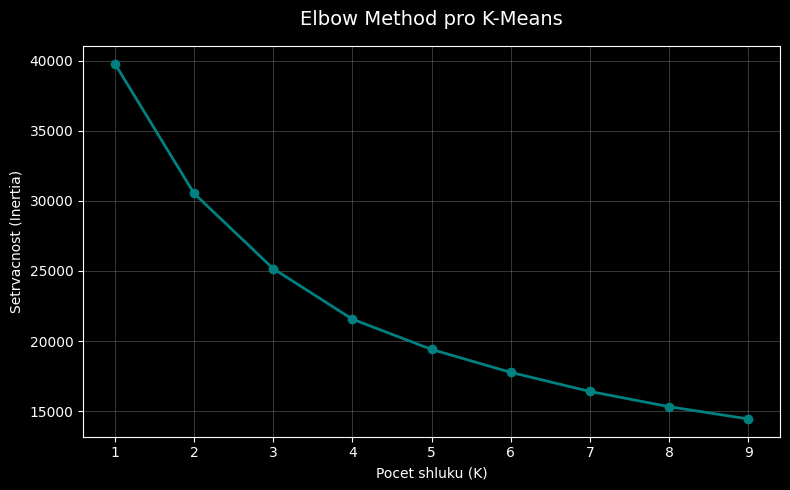

In [2]:
inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', color='teal', linewidth=2)
plt.title('Elbow Method pro K-Means', color='white', fontsize=14, pad=15)
plt.xlabel('Pocet shluku (K)', color='white')
plt.ylabel('Setrvacnost (Inertia)', color='white')
plt.xticks(K_range, color='white')
plt.yticks(color='white')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Silhouette Score
Kvantitativni potvrzeni volby K — cim vyssi skore, tim lepe oddelene shluky. Mereno pro K=2..7.

--- Hledani optimalniho K pomoci Silhouette Score ---
  K=2  Silhouette: 0.228
  K=3  Silhouette: 0.243
  K=4  Silhouette: 0.217
  K=5  Silhouette: 0.192
  K=6  Silhouette: 0.194
  K=7  Silhouette: 0.195


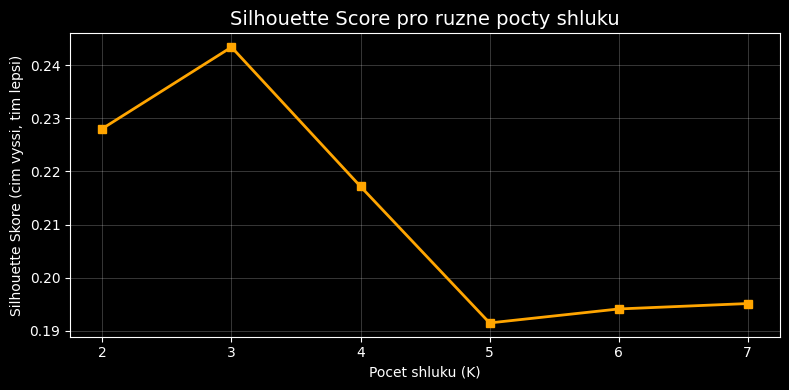


Nejlepsi K podle Silhouette: 3 (skore: 0.243)


In [3]:
print("--- Hledani optimalniho K pomoci Silhouette Score ---")
silhouette_scores = []
K_range_sil = range(2, 8)

for k in K_range_sil:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans_temp.fit_predict(X_cluster)
    score = silhouette_score(X_cluster, cluster_labels)
    silhouette_scores.append(score)
    print(f"  K={k}  Silhouette: {score:.3f}")

plt.figure(figsize=(8, 4))
plt.plot(K_range_sil, silhouette_scores, marker='s', color='orange', linewidth=2)
plt.title('Silhouette Score pro ruzne pocty shluku', color='white', fontsize=14)
plt.xlabel('Pocet shluku (K)', color='white')
plt.ylabel('Silhouette Skore (cim vyssi, tim lepsi)', color='white')
plt.xticks(K_range_sil, color='white')
plt.yticks(color='white')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_k = list(K_range_sil)[silhouette_scores.index(max(silhouette_scores))]
print(f"\nNejlepsi K podle Silhouette: {best_k} (skore: {max(silhouette_scores):.3f})")

## Trenink finálního modelu
Nastavte `OPTIMAL_K` na zaklade grafu vyse.

In [4]:
OPTIMAL_K = 3  # <-- upravte dle Elbow + Silhouette grafu

kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
X_cluster['Cluster'] = kmeans_final.fit_predict(X_cluster)
X_cluster['Dropout'] = y_all.values

print(f"Rozlozeni shluku:")
print(X_cluster['Cluster'].value_counts().sort_index())

Rozlozeni shluku:
Cluster
0    4298
1    1103
2    4599
Name: count, dtype: int64


## PCA pro vizualizaci (2D projekce)

In [5]:
pca = PCA(n_components=2, random_state=42)
pca.fit(X_cluster[cols_for_clustering])

print(f"Vysvetlena variance: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}")
print(f"Celkem: {sum(pca.explained_variance_ratio_):.1%}")

Vysvetlena variance: PC1=35.3%, PC2=25.3%
Celkem: 60.5%


## Ulozeni vystupu

In [6]:
os.makedirs('../models',           exist_ok=True)
os.makedirs('../results',           exist_ok=True)
os.makedirs('../data/processed',    exist_ok=True)

# Modely
joblib.dump(kmeans_final,        '../models/kmeans_final.pkl')
joblib.dump(pca,                 '../models/pca_2d.pkl')
print("  models/kmeans_final.pkl")
print("  models/pca_2d.pkl")

# Data se stitky pro downstream notebooky
joblib.dump({
    'X_cluster':          X_cluster,
    'cols_for_clustering': cols_for_clustering,
    'OPTIMAL_K':           OPTIMAL_K,
}, '../data/processed/clustered_data.pkl')
print("  data/processed/clustered_data.pkl")

# Skore pro pripadne preploceni bez retreningu
joblib.dump({'K_range': list(K_range),       'inertia': inertia},           '../results/elbow_scores.pkl')
joblib.dump({'K_range': list(K_range_sil),   'scores':  silhouette_scores}, '../results/silhouette_scores.pkl')
print("  results/elbow_scores.pkl")
print("  results/silhouette_scores.pkl")

print("\nVse ulozeno.")

  models/kmeans_final.pkl
  models/pca_2d.pkl
  data/processed/clustered_data.pkl
  results/elbow_scores.pkl
  results/silhouette_scores.pkl

Vse ulozeno.
